# Static XAS — per-shot analysis

Load per-shot (VLS, GMD) data produced by `compute_static_xas.py`, then:

1. Plot the per-shot GMD vs. mean-VLS correlation (all energies pooled).
2. Set GMD bin edges and bin shots per energy.
3. Replicate the standard aggregate plots: shot counts, mean GMD, VLS spectra, XAS(E).

In [10]:
import sys
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

%matplotlib inline

# Locate repo root by walking up from cwd.
cwd = Path.cwd().resolve()
repo_root = None
for p in [cwd] + list(cwd.parents):
    if (p / "analysis" / "scripts").exists():
        repo_root = p
        break
if repo_root is None:
    raise RuntimeError("Could not locate repository root.")
sys.path.insert(0, str(repo_root / "analysis" / "scripts"))

import config as path_config

## Config

Point `INPUT_H5` at the file produced by `compute_static_xas.py` and
set `GMD_EDGES` for the binned analysis below.

In [11]:
RUN_NO   = 58793
INPUT_H5 = Path(path_config.COMBINED_DIR).parent / "xas_static" / f"run{RUN_NO}_static_xas.h5"

# GMD bin edges (uJ). Adjust to match the intensity distribution of the run.
GMD_EDGES = np.array([0.0, 0.4, 0.8, 1.6, 3.2, 6.4, 12.8])

## Load data

In [12]:
with h5py.File(INPUT_H5, "r") as f:
    vls              = f["vls"][...]              # (N_E, N_shots, n_pixels)
    gmd              = f["gmd"][...]              # (N_E, N_shots)
    n_shots          = f["n_shots"][...]          # (N_E,)
    nominal_energies = f["nominal_energies"][...]  # (N_E,)
    vls_pixels       = f["vls_pixels"][...]        # (n_pixels,)
    attrs            = dict(f.attrs)

N_E, N_shots_max, n_pixels = vls.shape
print(f"file       : {INPUT_H5}")
print(f"run        : {attrs.get('run_no')}")
print(f"shape      : N_E={N_E}, N_shots_max={N_shots_max}, n_pixels={n_pixels}")
print(f"E range    : {nominal_energies[0]:.2f} .. {nominal_energies[-1]:.2f} eV")
print(f"total shots: {int(n_shots.sum())}")
print(f"sections   : detected={attrs.get('n_sections_detected')}, used={attrs.get('n_sections_used')}")
print(f"VLS ROI    : {attrs.get('vls_crop_roi')}")
print(f"signal bunches: {attrs.get('signal_bunch_range')}")

file       : /Users/hukaiyu/Desktop/PhD/FLASH Beamtime 202605/glycine26/11022188/processed/xas_static/run58793_static_xas.h5
run        : 58793
shape      : N_E=31, N_shots_max=71010, n_pixels=200
E range    : 270.00 .. 285.00 eV
total shots: 1141170
sections   : detected=31, used=31
VLS ROI    : [450 650]
signal bunches: [10 40]


## GMD vs. integrated VLS correlation

All shots across all energies pooled. A near-linear correlation through the
origin confirms that background subtraction and train alignment are intact.

1141170 valid shots out of 2201310 total slots


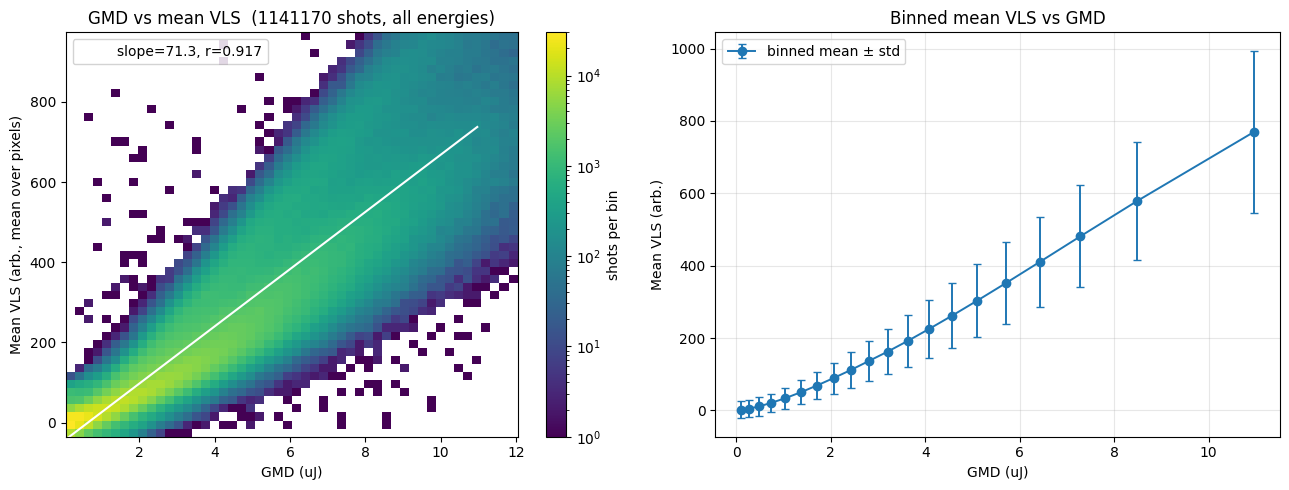

In [13]:
# Flatten over all energies and remove NaN-padded slots.
gmd_flat = gmd.reshape(-1)                          # (N_E * N_shots_max,)
vls_flat = vls.reshape(-1, n_pixels)                # (N_E * N_shots_max, n_pixels)
ok = np.isfinite(gmd_flat) & np.all(np.isfinite(vls_flat), axis=1)
x_gmd = gmd_flat[ok]
y_vls = np.nanmean(vls_flat[ok], axis=1)            # mean over pixels per shot

print(f"{ok.sum()} valid shots out of {gmd_flat.size} total slots")

# Percentile-based GMD binning for the right panel.
bin_edges = np.percentile(x_gmd, np.linspace(0, 100, 21))
bin_idx   = np.digitize(x_gmd, bin_edges) - 1
bin_idx   = np.clip(bin_idx, 0, len(bin_edges) - 2)
bin_cents = 0.5 * (bin_edges[:-1] + bin_edges[1:])
y_mean    = np.array([np.nanmean(y_vls[bin_idx == b]) if np.any(bin_idx == b) else np.nan
                      for b in range(len(bin_cents))])
y_std     = np.array([np.nanstd(y_vls[bin_idx == b])  if np.any(bin_idx == b) else np.nan
                      for b in range(len(bin_cents))])
x_mean    = np.array([np.nanmean(x_gmd[bin_idx == b]) if np.any(bin_idx == b) else np.nan
                      for b in range(len(bin_cents))])

r = float(np.corrcoef(x_gmd, y_vls)[0, 1])
slope, intercept = np.polyfit(x_gmd, y_vls, 1)
xl = np.linspace(x_mean[np.isfinite(x_mean)].min(),
                 x_mean[np.isfinite(x_mean)].max(), 50)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

h = ax1.hist2d(
    x_gmd, y_vls,
    bins=[np.linspace(np.percentile(x_gmd, 1),  np.percentile(x_gmd, 99),  51),
          np.linspace(np.percentile(y_vls, 1),  np.percentile(y_vls, 99),  51)],
    cmap="viridis", cmin=1, norm=mcolors.LogNorm(),
)
fig.colorbar(h[3], ax=ax1, label="shots per bin")
ax1.plot(xl, slope * xl + intercept, color="white", lw=1.5,
         label=f"slope={slope:.3g}, r={r:.3f}")
ax1.set_xlabel("GMD (uJ)")
ax1.set_ylabel("Mean VLS (arb., mean over pixels)")
ax1.set_title(f"GMD vs mean VLS  ({ok.sum()} shots, all energies)")
ax1.legend(loc="upper left", framealpha=0.85)

ax2.errorbar(x_mean, y_mean, yerr=y_std, fmt="o-", color="tab:blue",
             capsize=3, lw=1.4, label="binned mean ± std")
ax2.set_xlabel("GMD (uJ)")
ax2.set_ylabel("Mean VLS (arb.)")
ax2.set_title("Binned mean VLS vs GMD")
ax2.grid(alpha=0.3)
ax2.legend()
fig.tight_layout()
plt.show()

## GMD binning per energy

Bin each energy's shots by `GMD_EDGES`, accumulate sums, and normalise
to per-bin means.

In [14]:
N_GMD = len(GMD_EDGES) - 1
gmd_cents = 0.5 * (GMD_EDGES[:-1] + GMD_EDGES[1:])

# Accumulators.
A_sum     = np.zeros((N_E, N_GMD, n_pixels), dtype=np.float64)
G_sum     = np.zeros((N_E, N_GMD),           dtype=np.float64)
n_per_bin = np.zeros((N_E, N_GMD),           dtype=np.int64)

for ie in range(N_E):
    n  = int(n_shots[ie])
    G  = gmd[ie, :n]           # (n,)
    A  = vls[ie, :n, :]        # (n, n_pixels)
    finite = np.isfinite(G) & np.all(np.isfinite(A), axis=1)
    bins   = np.digitize(G[finite], GMD_EDGES) - 1
    in_range = (bins >= 0) & (bins < N_GMD)
    A_f, G_f, bins_f = A[finite][in_range], G[finite][in_range], bins[in_range]
    for b in np.unique(bins_f):
        mask = bins_f == b
        n_per_bin[ie, b] += int(mask.sum())
        G_sum[ie, b]     += G_f[mask].sum()
        A_sum[ie, b]     += A_f[mask].sum(axis=0)

safe_n = np.where(n_per_bin > 0, n_per_bin, 1).astype(np.float64)
G_mean = np.where(n_per_bin > 0, G_sum / safe_n, np.nan)
A_mean = np.where(n_per_bin[:, :, None] > 0, A_sum / safe_n[:, :, None], np.nan)

print(f"GMD edges  : {GMD_EDGES}")
print(f"Total shots binned: {int(n_per_bin.sum())}")
print(f"Shape: A_mean={A_mean.shape}, G_mean={G_mean.shape}, n_per_bin={n_per_bin.shape}")

GMD edges  : [ 0.   0.4  0.8  1.6  3.2  6.4 12.8]
Total shots binned: 1134133
Shape: A_mean=(31, 6, 200), G_mean=(31, 6), n_per_bin=(31, 6)


## Shot counts per (energy, GMD) bin

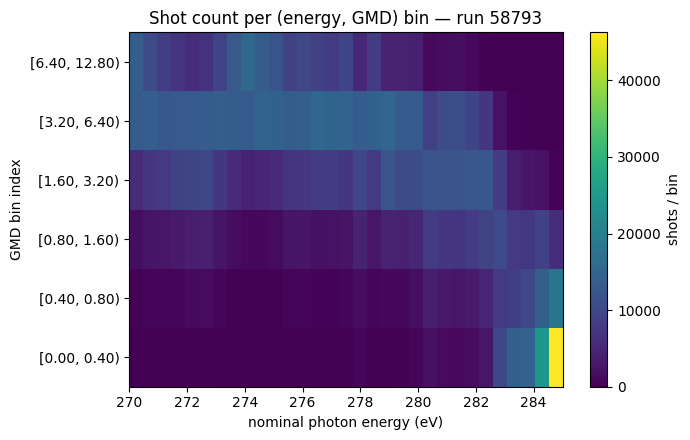

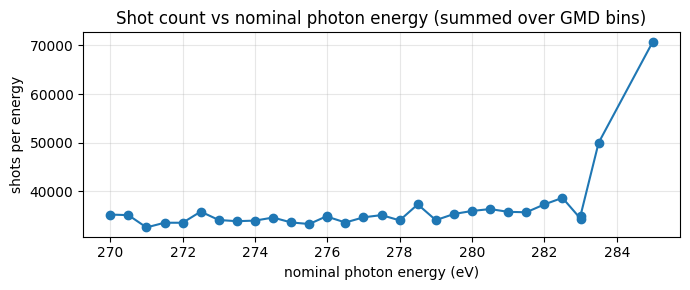

In [15]:
fig, ax = plt.subplots(figsize=(7.0, 4.5))
im = ax.imshow(
    n_per_bin.T,
    aspect="auto", origin="lower",
    extent=[nominal_energies[0], nominal_energies[-1], 0, N_GMD],
    cmap="viridis",
)
fig.colorbar(im, ax=ax, label="shots / bin")
ax.set_xlabel("nominal photon energy (eV)")
ax.set_ylabel("GMD bin index")
ax.set_yticks(np.arange(N_GMD) + 0.5)
ax.set_yticklabels([f"[{GMD_EDGES[i]:.2f}, {GMD_EDGES[i+1]:.2f})" for i in range(N_GMD)])
ax.set_title(f"Shot count per (energy, GMD) bin — run {RUN_NO}")
fig.tight_layout()
plt.show()

# Marginal: shots per energy.
fig, ax = plt.subplots(figsize=(7.0, 3.0))
ax.plot(nominal_energies, n_per_bin.sum(axis=1), "o-", color="tab:blue")
ax.set_xlabel("nominal photon energy (eV)")
ax.set_ylabel("shots per energy")
ax.set_title("Shot count vs nominal photon energy (summed over GMD bins)")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Mean GMD per (energy, GMD) bin

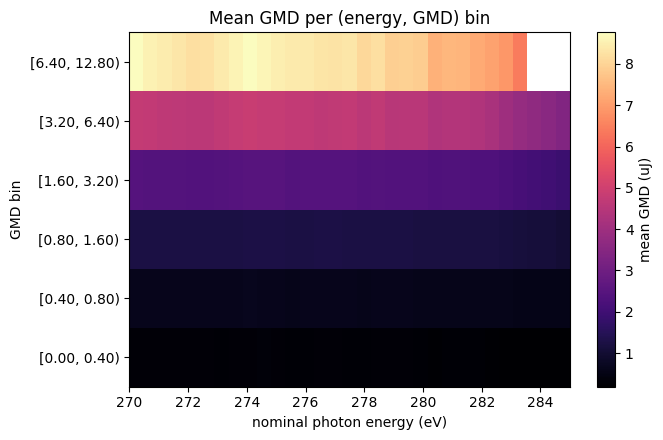

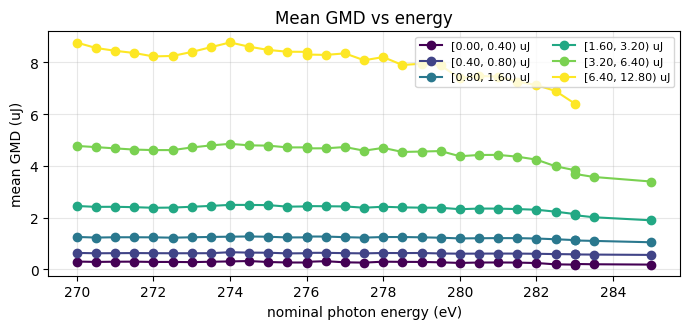

In [16]:
fig, ax = plt.subplots(figsize=(7.0, 4.5))
im = ax.imshow(
    G_mean.T,
    aspect="auto", origin="lower",
    extent=[nominal_energies[0], nominal_energies[-1], 0, N_GMD],
    cmap="magma",
)
fig.colorbar(im, ax=ax, label="mean GMD (uJ)")
ax.set_xlabel("nominal photon energy (eV)")
ax.set_ylabel("GMD bin")
ax.set_yticks(np.arange(N_GMD) + 0.5)
ax.set_yticklabels([f"[{GMD_EDGES[i]:.2f}, {GMD_EDGES[i+1]:.2f})" for i in range(N_GMD)])
ax.set_title("Mean GMD per (energy, GMD) bin")
fig.tight_layout()
plt.show()

# Mean GMD vs energy, one line per GMD bin.
fig, ax = plt.subplots(figsize=(7.0, 3.4))
cmap = plt.get_cmap("viridis")
for g in range(N_GMD):
    ax.plot(nominal_energies, G_mean[:, g], "o-",
            color=cmap(g / max(N_GMD - 1, 1)),
            label=f"[{GMD_EDGES[g]:.2f}, {GMD_EDGES[g+1]:.2f}) uJ")
ax.set_xlabel("nominal photon energy (eV)")
ax.set_ylabel("mean GMD (uJ)")
ax.set_title("Mean GMD vs energy")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

## Mean VLS spectrum per (energy, GMD bin)

Grid of subplots, one per nominal energy. Each panel shows `(GMD bin, pixel)`
so spectral shape runs horizontally and intensity dependence vertically.

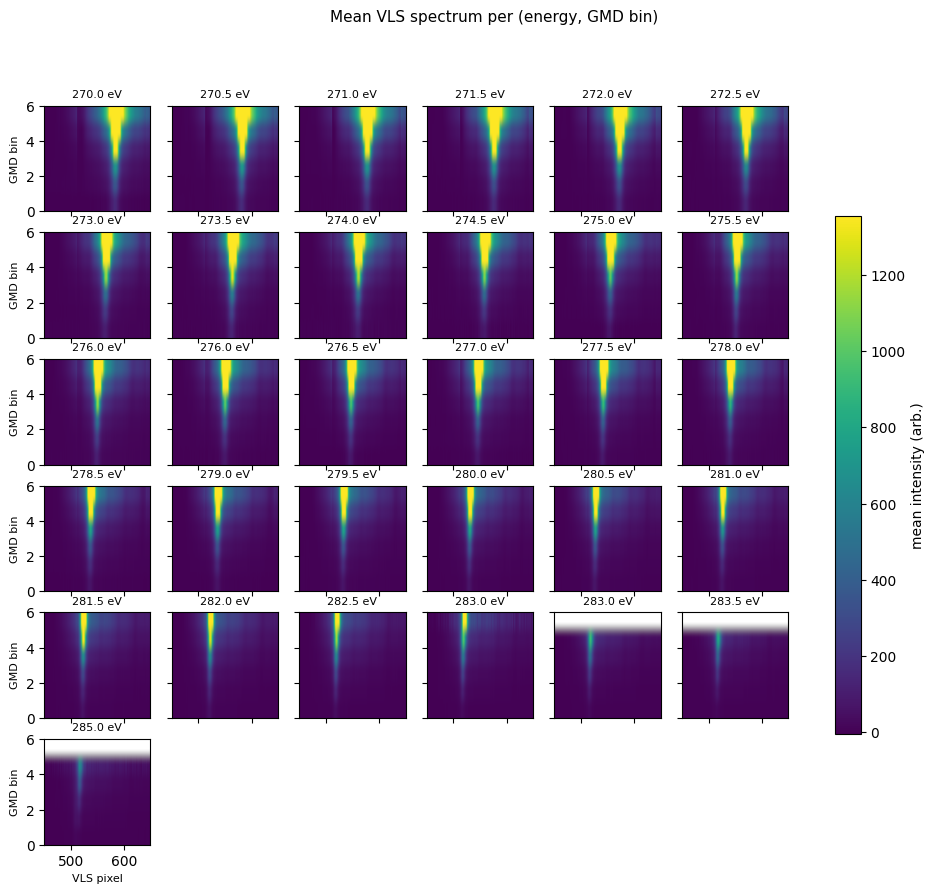

In [17]:
ncols = int(np.ceil(np.sqrt(N_E)))
nrows = int(np.ceil(N_E / ncols))

finite_mask = np.isfinite(A_mean)
vmin, vmax = (np.nanpercentile(A_mean[finite_mask], [2, 98])
              if finite_mask.any() else (0.0, 1.0))

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(2.0 * ncols, 1.6 * nrows),
                         sharex=True, sharey=True, squeeze=False)
for k in range(nrows * ncols):
    r, c = divmod(k, ncols)
    ax = axes[r][c]
    if k >= N_E:
        ax.axis("off")
        continue
    im = ax.imshow(
        A_mean[k],                   # (N_GMD, n_pixels)
        aspect="auto", origin="lower",
        extent=[vls_pixels[0], vls_pixels[-1], 0, N_GMD],
        cmap="viridis", vmin=vmin, vmax=vmax,
    )
    ax.set_title(f"{nominal_energies[k]:.1f} eV", fontsize=8)
    if r == nrows - 1:
        ax.set_xlabel("VLS pixel", fontsize=8)
    if c == 0:
        ax.set_ylabel("GMD bin", fontsize=8)
fig.suptitle("Mean VLS spectrum per (energy, GMD bin)", fontsize=11)
fig.colorbar(im, ax=axes, shrink=0.7, label="mean intensity (arb.)")
plt.show()

## XAS(E) per GMD bin

`XAS = <GMD> / sum_pixels(<VLS>)` — one line per GMD bin.

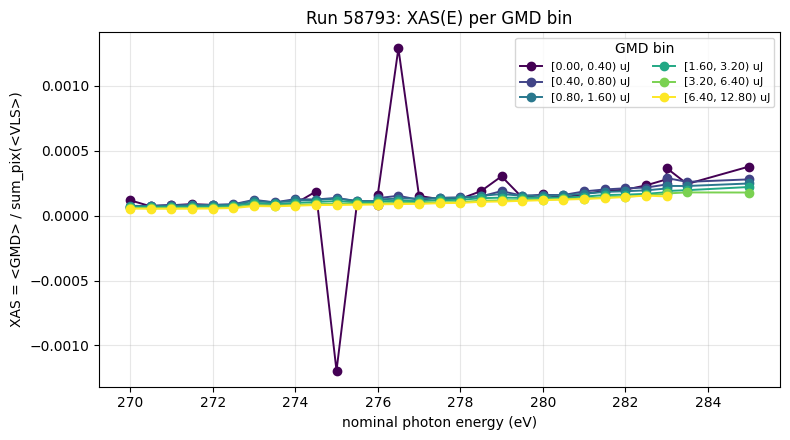

   E (eV)  bin0 XAS    bin1 XAS    bin2 XAS    bin3 XAS    bin4 XAS    bin5 XAS  
---------------------------------------------------------------------------
   270.00  0.0001181  6.901e-05  7.568e-05  6.877e-05  5.874e-05  5.404e-05
   270.50  7.125e-05  7.732e-05  7.369e-05  6.602e-05  5.748e-05   5.33e-05
   271.00  8.031e-05  8.174e-05  7.614e-05   6.73e-05  5.749e-05   5.34e-05
   271.50  8.876e-05  8.229e-05  7.927e-05  6.901e-05  5.818e-05  5.353e-05
   272.00  8.242e-05  8.301e-05   8.11e-05  6.995e-05   5.92e-05  5.494e-05
   272.50  8.305e-05  8.755e-05  8.463e-05   7.37e-05  6.334e-05  5.851e-05
   273.00  9.422e-05  0.0001218  0.0001148  9.863e-05  8.176e-05  7.354e-05
   273.50  9.107e-05  0.0001023  0.0001012  8.912e-05   7.69e-05  7.191e-05
   274.00  9.283e-05  0.0001272   0.000117  9.766e-05  8.287e-05  7.648e-05
   274.50  0.0001858  0.0001243  0.0001206  0.0001054  8.923e-05  8.169e-05
   275.00  -0.001195  0.0001367  0.0001314  0.0001121  9.181e-05  8.207e-05
   275

In [18]:
vls_sum = np.nansum(A_mean, axis=2)            # (N_E, N_GMD)
with np.errstate(divide="ignore", invalid="ignore"):
    xas = G_mean / vls_sum                      # (N_E, N_GMD)

fig, ax = plt.subplots(figsize=(8.0, 4.5))
cmap = plt.get_cmap("viridis")
for g in range(N_GMD):
    label = f"[{GMD_EDGES[g]:.2f}, {GMD_EDGES[g+1]:.2f}) uJ"
    ax.plot(nominal_energies, xas[:, g], "o-",
            color=cmap(g / max(N_GMD - 1, 1)),
            lw=1.4, label=label)
ax.set_xlabel("nominal photon energy (eV)")
ax.set_ylabel("XAS = <GMD> / sum_pix(<VLS>)")
ax.set_title(f"Run {RUN_NO}: XAS(E) per GMD bin")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, title="GMD bin", ncol=2)
fig.tight_layout()
plt.show()

# Summary table.
print(f"{'E (eV)':>9s}" + "".join(f"  bin{g} XAS  " for g in range(N_GMD)))
print("-" * (9 + 11 * N_GMD))
for k in range(N_E):
    row = f"{nominal_energies[k]:9.2f}"
    for g in range(N_GMD):
        row += f"  {xas[k, g]:9.4g}"
    print(row)